<a href="https://colab.research.google.com/github/fralfaro/MAT281/blob/main/docs/labs/lab_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# MAT281 - Laboratorio N°08

**Objetivo**: Aplicar técnicas de **machine learning no supervisado** para explorar, procesar y analizar conjuntos de datos con variables numéricas y categóricas.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.


## Clustering


<img src="https://www.svgrepo.com/show/253022/car.svg" width = "300" align="center"/>



El conjunto de datos **`vehiculos_procesado_con_grupos.csv`** recopila información sobre diversas características relevantes de distintos vehículos. El propósito de este ejercicio es **clasificar los vehículos en diferentes categorías**, utilizando como base las variables descritas en la tabla de atributos.

El análisis presenta un desafío adicional debido a la **naturaleza mixta de los datos**: se incluyen tanto variables **numéricas** (ej. dimensiones, consumo, emisiones) como **categóricas** (ej. tipo de tracción, tipo de combustible), lo que requiere aplicar técnicas de preprocesamiento adecuadas antes de entrenar los modelos.

Como primer paso, procederemos a **cargar y explorar el conjunto de datos**, con el fin de familiarizarnos con su estructura y las características que servirán como base para la posterior clasificación.




**Descripción de los Datos:**

| **Nombre de la Columna**   | **Descripción**                                                                                                                                   |
|----------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------|
| **year**                   | El año en que el vehículo fue fabricado.                                                                                                          |
| **desplazamiento**          | La capacidad volumétrica del motor en litros. Indica la cantidad de aire y combustible que puede desplazar el motor durante una revolución.       |
| **cilindros**               | El número de cilindros que tiene el motor. Los cilindros son las cámaras donde ocurre la combustión interna en los motores de los vehículos.       |
| **co2**                     | Emisiones de dióxido de carbono del vehículo, medido en gramos por kilómetro. Es una medida de las emisiones de gases de efecto invernadero.       |
| **clase_tipo**              | La clase o tipo de vehículo, como vehículos especiales, deportivos, etc.                                                                         |
| **traccion_tipo**           | Tipo de tracción del vehículo, ya sea tracción en dos ruedas, en cuatro ruedas o en todas las ruedas.                                             |
| **transmision_tipo**        | Tipo de transmisión del vehículo, como automática, manual, entre otros.                                                                          |
| **combustible_tipo**        | Tipo de combustible que utiliza el vehículo, como gasolina, diésel, eléctrico, híbrido, etc.                                                     |
| **tamano_motor_tipo**       | Clasificación del tamaño del motor (por ejemplo, pequeño, mediano o grande), que generalmente se basa en la capacidad de desplazamiento.           |
| **consumo_tipo**            | Clasificación del nivel de consumo de combustible del vehículo, indicando si es alto, bajo, o muy alto.                                           |
| **co2_tipo**                | Clasificación de las emisiones de CO2 del vehículo, indicando si es alto, bajo, o muy alto.                                                       |
| **consumo_litros_milla**    | El consumo de combustible del vehículo, medido en litros por milla. Indica la eficiencia del vehículo en términos de consumo de combustible.        |



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans


%matplotlib inline

sns.set_palette("deep", desat=.6)
sns.set(rc={'figure.figsize':(11.7,8.27)})

In [2]:
# cargar datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/MAT281/main/docs/labs/data/vehiculos_procesado_con_grupos.csv", sep=",")\
       .drop(
            ["fabricante",
             "modelo",
             "transmision",
             "traccion",
             "clase",
             "combustible",
             "consumo"],

          axis=1)

df.head()

,year,desplazamiento,cilindros,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla
0,1984,2.5,4.0,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671
1,1984,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,1985,2.5,4.0,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588
3,1985,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,1987,3.8,6.0,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588


En este caso, no solo se tienen datos numéricos, sino que también categóricos. Además, tenemos problemas de datos **vacíos (Nan)**. Así que para resolver este problema, seguiremos varios pasos:

### 1.- Normalizar datos

- Cree un conjunto de datos con las variables numéricas, además, para cada dato vacía, rellene con el promedio asociado a esa columna. Finalmente, normalize los datos mediante el procesamiento **MinMaxScaler** de **sklearn**.
- Cree un conjunto de datos con las variables categóricas , además, transforme de variables categoricas a numericas ocupando el comando **get_dummies** de pandas ([referencia](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html)). Explique a grande rasgo como se realiza la codificación de variables numéricas a categóricas.

- Junte ambos dataset en uno, llamado **df_procesado**.

In [4]:
#var num
import unicodedata
datos_numericos=df.select_dtypes(include=['float64'])
datos_numericos=datos_numericos.fillna(datos_numericos.mean())
scaler=MinMaxScaler()
datos_numericos_normalizados=scaler.fit_transform(datos_numericos)
datos_numericos_normalizados=pd.DataFrame(datos_numericos_normalizados, columns=datos_numericos.columns)
#var cat
datos_categoricos=df.select_dtypes(include=['object'])
datos_categoricos=pd.get_dummies(datos_categoricos)
#junte
df_procesado=pd.concat([datos_numericos_normalizados,datos_categoricos],axis=1)
new_col=[]
for col in df_procesado.columns:
  col=col.lower()
  col=col.replace(" ","_")
  col= unicodedata.normalize('NFKD', col).encode('ascii', 'ignore').decode('ascii')
  new_col.append(col)
df_procesado.columns=new_col
df_procesado.head()

,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_camionetas,clase_tipo_coche_familiar,clase_tipo_coches_grandes,clase_tipo_coches_medianos,clase_tipo_coches_pequenos,clase_tipo_deportivos,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy_alto,consumo_tipo_muy_bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy_alto,co2_tipo_muy_bajo
0,0.243590,0.142857,0.398014,0.331027,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
1,0.461538,0.285714,0.527672,0.475113,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0.243590,0.142857,0.424351,0.360294,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
3,0.461538,0.285714,0.527672,0.475113,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
4,0.410256,0.285714,0.424351,0.360294,False,False,False,True,False,False,...,True,False,False,False,False,True,False,False,False,False


### 2.- Realizar ajuste mediante kmeans

Una vez depurado el conjunto de datos, es momento de aplicar el algoritmo de **kmeans**.

1. Ajuste el modelo de **kmeans** sobre el conjunto de datos, con un total de **8 clusters**.
2. Asociar a cada individuo el correspondiente cluster y calcular valor de los centroides de cada cluster.
3. Realizar un resumen de las principales cualidades de cada cluster. Para  esto debe calcular (para cluster) las siguientes medidas de resumen:
    * Valor promedio de las variables numérica
    * Moda para las variables numericas

In [5]:
# FIXME
kmeans=KMeans(n_clusters=8,n_init=25,random_state=123)
kmeans.fit(df_procesado)
centroids=kmeans.cluster_centers_
clusters=kmeans.labels_
df_procesado['cluster']=clusters
df_procesado['cluster']=df_procesado['cluster'].astype('category')

cluster_summaries = {}
for i in range(8):
    cluster_data = df_procesado[clusters == i]  # Filtrar datos por cluster
    numerical_means = cluster_data.select_dtypes(include=['number']).mean()  # Promedio de variables numéricas
    categorical_modes = cluster_data.select_dtypes(include=['object','category']).mode().iloc[0]  # Moda de variables categóricas
    cluster_summaries[i] = {
        'numerical_means': numerical_means,
        'categorical_modes': categorical_modes
    }
#resumen
for cluster, summary in cluster_summaries.items():
    print(f"Cluster {cluster}:")
    print("Promedio de variables numéricas:")
    print(summary['numerical_means'])

Cluster 0:
Promedio de variables numéricas:
desplazamiento          0.585590
cilindros               0.430797
co2                     0.510289
consumo_litros_milla    0.454503
dtype: float64
Cluster 1:
Promedio de variables numéricas:
desplazamiento          0.334035
cilindros               0.258127
co2                     0.354211
consumo_litros_milla    0.281400
dtype: float64
Cluster 2:
Promedio de variables numéricas:
desplazamiento          0.236153
cilindros               0.157991
co2                     0.257461
consumo_litros_milla    0.172659
dtype: float64
Cluster 3:
Promedio de variables numéricas:
desplazamiento          0.250916
cilindros               0.195881
co2                     0.304474
consumo_litros_milla    0.226879
dtype: float64
Cluster 4:
Promedio de variables numéricas:
desplazamiento          0.148941
cilindros               0.142350
co2                     0.236470
consumo_litros_milla    0.151675
dtype: float64
Cluster 5:
Promedio de variables numéricas:
d

### 3.- Elegir Número de cluster

Estime mediante la **regla del codo**, el número de cluster apropiados para el caso.
Para efectos prácticos, eliga la siguiente secuencia como número de clusters a comparar:

$$[5, 10, 20, 30, 50, 75, 100, 200, 300]$$

Una vez realizado el gráfico, saque sus propias conclusiones del caso.

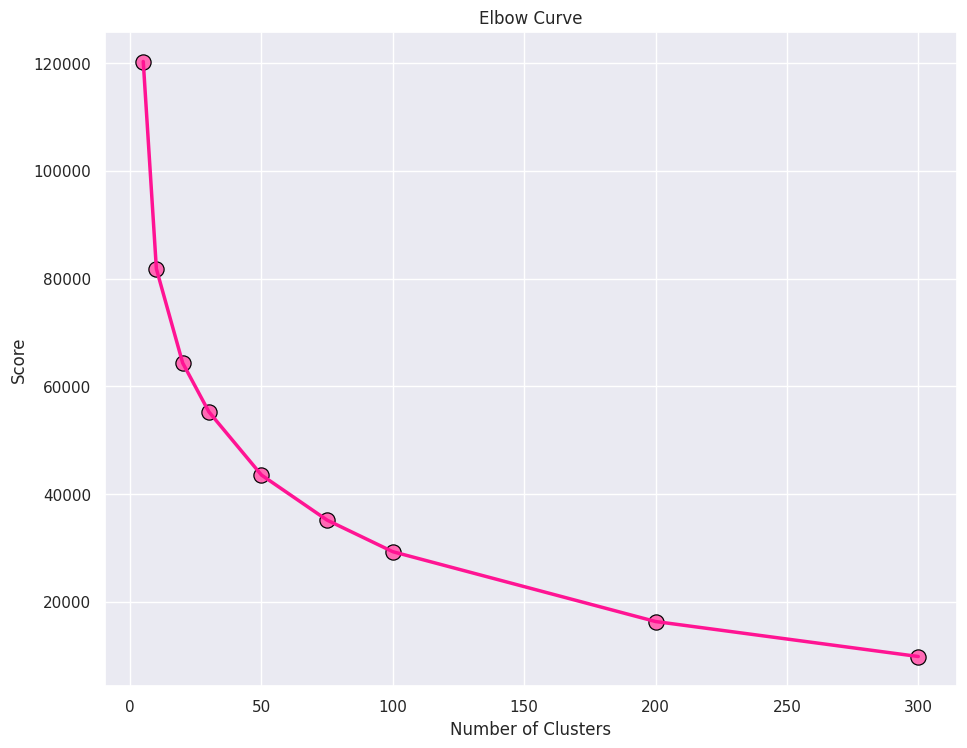

In [7]:
rango_clusters=[5, 10, 20, 30, 50, 75, 100, 200, 300]
kmeans = [KMeans(n_clusters=i, n_init=10) for i in rango_clusters]
score = [kmeans[i].fit(df_procesado).inertia_ for i in range(len(kmeans))]

df_Elbow = pd.DataFrame({'Number of Clusters': rango_clusters, 'Score': score})

df_Elbow.head()

fig, ax = plt.subplots(figsize=(11, 8.5))
plt.title('Elbow Curve')
sns.lineplot(x="Number of Clusters",
             y="Score",
            data=df_Elbow,
            color="#ff1493",   # rosa fuerte (DeepPink)
            linewidth=2.5
            )
sns.scatterplot(x="Number of Clusters",
             y="Score",
             data=df_Elbow,
             color="#ff69b4",
             s=120,
             edgecolor="black"
)
plt.show()

Al observar el gráfico resultante, se pueden obtener conclusiones sobre el número apropiado de clusters. La regla del codo sugiere elegir el número de clusters donde la reducción en la inercia se estabiliza significativamente. En otras palabras, se busca el punto en el gráfico donde la curva de inercia comienza a aplanarse o forma un codo.

El gráfico es muy poco indicativo al ser demasiados clusters, aunque 200 es muy buena medida, se pierde el proposito de hacer clusters.

Para que el gráfico sea mejor, escogeremos clusters cerca de donde se dobla el codo, es decir, alrededor de 80.

## Reducción de Dimensionalidad

<img src="https://1000logos.net/wp-content/uploads/2020/11/Wine-Logo-old.png" width = "300" align="center"/>


Para este ejercicio utilizaremos el **Wine Dataset**, un conjunto de datos clásico disponible en la librería **scikit-learn** y en el repositorio de la **UCI Machine Learning**.
Este dataset contiene información de **178 muestras de vino** provenientes de la región italiana de *Piamonte*. Cada vino pertenece a una de **tres variedades de uva** (*clases*), que actúan como etiquetas para el análisis supervisado, pero aquí se usarán solo como referencia en la visualización.

Cada muestra está descrita por **13 variables químicas** obtenidas de un análisis de laboratorio, entre ellas:

* **Alcohol**: porcentaje de alcohol en el vino.
* **Malic acid**: concentración de ácido málico.
* **Ash**: contenido de ceniza.
* **Alcalinity of ash**: alcalinidad de la ceniza.
* **Magnesium**: cantidad de magnesio (mg/L).
* **Total phenols**: concentración total de fenoles.
* **Flavanoids**: tipo de fenoles con propiedades antioxidantes.
* **Nonflavanoid phenols**: fenoles que no son flavonoides.
* **Proanthocyanins**: compuestos relacionados con el color y el sabor.
* **Color intensity**: intensidad del color del vino.
* **Hue**: matiz del color.
* **OD280/OD315 of diluted wines**: relación de absorbancia que mide la calidad del vino.
* **Proline**: concentración de prolina (un aminoácido).

Estas características permiten representar cada vino como un punto en un espacio de **13 dimensiones**.

El objetivo del análisis con este dataset es **reducir la dimensionalidad** para visualizar y explorar patrones en los datos. Para ello aplicaremos:

* **PCA (Principal Component Analysis):** identificar las combinaciones lineales de variables que explican la mayor varianza en el conjunto.
* **t-SNE (t-distributed Stochastic Neighbor Embedding):** mapear las muestras a 2D o 3D, preservando relaciones de vecindad y estructuras no lineales.

La comparación entre ambas técnicas permitirá observar cómo las tres clases de vinos se diferencian en el espacio reducido y discutir la utilidad de la reducción de dimensionalidad en datos con mayor número de variables que en el caso del dataset *Wine*.



In [8]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

In [9]:
# cargar dataset
dataset = load_wine()

# nombres de las variables
features = dataset.feature_names
target = 'wine_class'

# construir DataFrame
wine = pd.DataFrame(dataset.data, columns=features)
wine[target] = dataset.target

# ver primeras filas
wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0




### 1. **Análisis detallado con PCA**

* Calcular la **varianza explicada** por cada componente principal y representar el gráfico de varianza acumulada, identificando cuántos componentes son necesarios para capturar al menos el **90–95% de la información**.
* Construir tablas y gráficos que muestren cómo las observaciones (vinos) se proyectan en las primeras componentes principales.
* Analizar los **loadings** (coeficientes de cada variable en los componentes) e interpretar qué características químicas del vino (alcohol, fenoles, color, etc.) tienen mayor influencia en las nuevas dimensiones.
* Visualizar los datos reducidos a 2D o 3D e interpretar si las **tres variedades de vino** se separan de forma clara en el espacio proyectado.



Varianza explicada por cada componente principal:
PC1     0.361988
PC2     0.192075
PC3     0.111236
PC4     0.070690
PC5     0.065633
PC6     0.049358
PC7     0.042387
PC8     0.026807
PC9     0.022222
PC10    0.019300
PC11    0.017368
PC12    0.012982
PC13    0.007952
dtype: float64

Varianza acumulada:
PC1     0.361988
PC2     0.554063
PC3     0.665300
PC4     0.735990
PC5     0.801623
PC6     0.850981
PC7     0.893368
PC8     0.920175
PC9     0.942397
PC10    0.961697
PC11    0.979066
PC12    0.992048
PC13    1.000000
dtype: float64


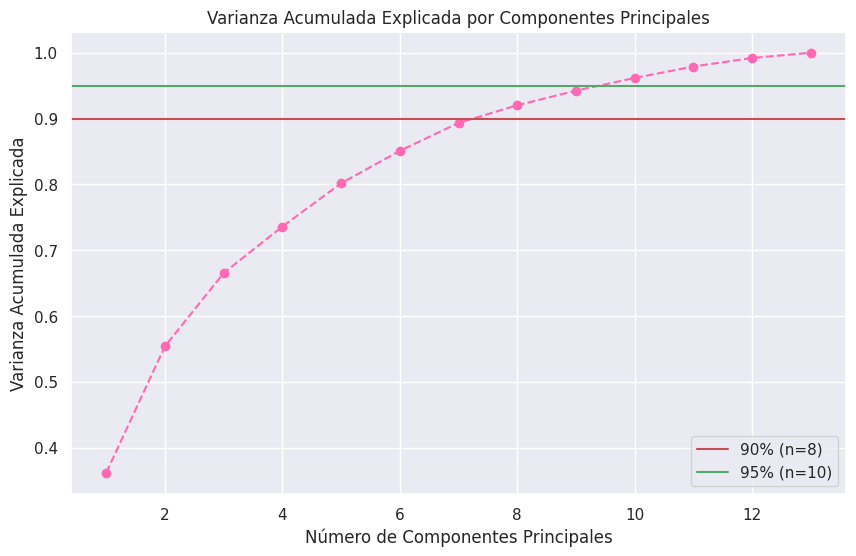


Loadings (Coeficientes de las variables en las primeras 3 Componentes Principales):
                                 PC1     PC2     PC3
alcohol                       0.1443  0.4837 -0.2074
malic_acid                   -0.2452  0.2249  0.0890
ash                          -0.0021  0.3161  0.6262
alcalinity_of_ash            -0.2393 -0.0106  0.6121
magnesium                     0.1420  0.2996  0.1308
total_phenols                 0.3947  0.0650  0.1462
flavanoids                    0.4229 -0.0034  0.1507
nonflavanoid_phenols         -0.2985  0.0288  0.1704
proanthocyanins               0.3134  0.0393  0.1495
color_intensity              -0.0886  0.5300 -0.1373
hue                           0.2967 -0.2792  0.0852
od280/od315_of_diluted_wines  0.3762 -0.1645  0.1660
proline                       0.2868  0.3649 -0.1267

Interpretación de los Loadings (Cualidades de las nuevas dimensiones):
PC1 (que explica 36.20% de la varianza):
Mayor influencia positiva (Ej: Vinos de Mayor Calidad):
flav

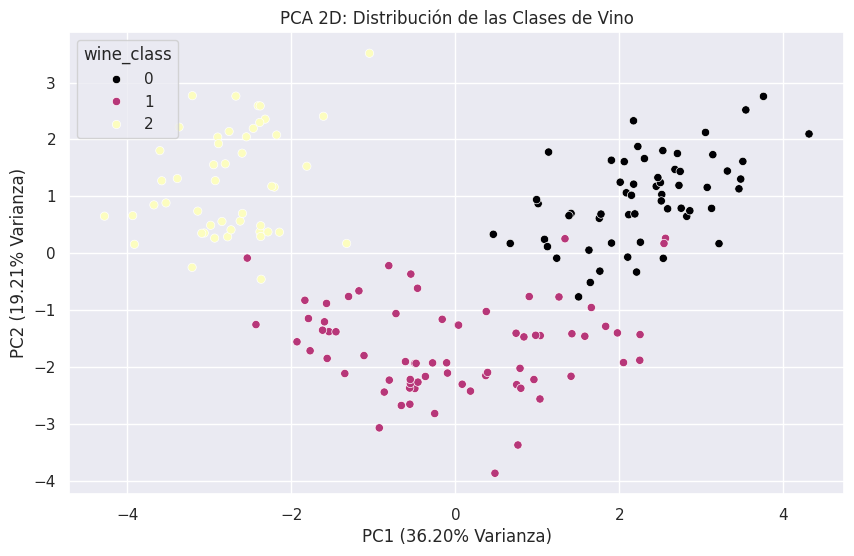

In [28]:
from sklearn.preprocessing import StandardScaler
X = wine.drop(target, axis=1)
y = wine[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca_full = PCA()
pca_full.fit(X_scaled)
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
print("Varianza explicada por cada componente principal:")
print(pd.Series(explained_variance_ratio, index=[f'PC{i+1}' for i in range(len(explained_variance_ratio))]))
print("\nVarianza acumulada:")
print(pd.Series(cumulative_variance, index=[f'PC{i+1}' for i in range(len(cumulative_variance))]))

# Grafico var ac
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='hotpink')
plt.title('Varianza Acumulada Explicada por Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada Explicada')
plt.grid(True)


n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
plt.axhline(y=0.90, color='r', linestyle='-', label=f'90% (n={n_90})')
plt.axhline(y=0.95, color='g', linestyle='-', label=f'95% (n={n_95})')
plt.legend(loc='best')
plt.show()
loadings = pd.DataFrame(
    pca_full.components_[:3].T,
    columns=['PC1', 'PC2', 'PC3'],
    index=X.columns
).round(4)
print("\nLoadings (Coeficientes de las variables en las primeras 3 Componentes Principales):")
print(loadings)
print("\nInterpretación de los Loadings (Cualidades de las nuevas dimensiones):")
print(f"PC1 (que explica {explained_variance_ratio[0]*100:.2f}% de la varianza):")
pc1_interpretation = loadings['PC1'].sort_values(ascending=False)
print("Mayor influencia positiva (Ej: Vinos de Mayor Calidad):")
print(pc1_interpretation[pc1_interpretation > 0.3])
print("Mayor influencia negativa (Ej: Vinos de Menor Calidad o Distintos):")
print(pc1_interpretation[pc1_interpretation < -0.3])
print(f"\nPC2 (que explica {explained_variance_ratio[1]*100:.2f}% de la varianza):")
pc2_interpretation = loadings['PC2'].sort_values(ascending=False)
print("Mayor influencia positiva:")
print(pc2_interpretation[pc2_interpretation.abs() > 0.3])

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
df_pca['wine_class'] = y

# Gráfico 2D
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='wine_class',
    data=df_pca,
    palette='magma',
    legend='full'
)
plt.title('PCA 2D: Distribución de las Clases de Vino')
plt.xlabel(f'PC1 ({explained_variance_ratio[0]*100:.2f}% Varianza)')
plt.ylabel(f'PC2 ({explained_variance_ratio[1]*100:.2f}% Varianza)')
plt.grid(True)
plt.show()



### 2. **Análisis detallado con t-SNE**

* Aplicar **t-SNE** para reducir los datos a 2 dimensiones, probando diferentes configuraciones de hiperparámetros como *perplexity* y *learning rate*.
* Comparar las distintas visualizaciones obtenidas y discutir cómo los hiperparámetros afectan la estructura de los clústeres.
* Analizar si las **tres clases de vinos** forman agrupaciones definidas y si t-SNE logra capturar relaciones no lineales que PCA no refleja.



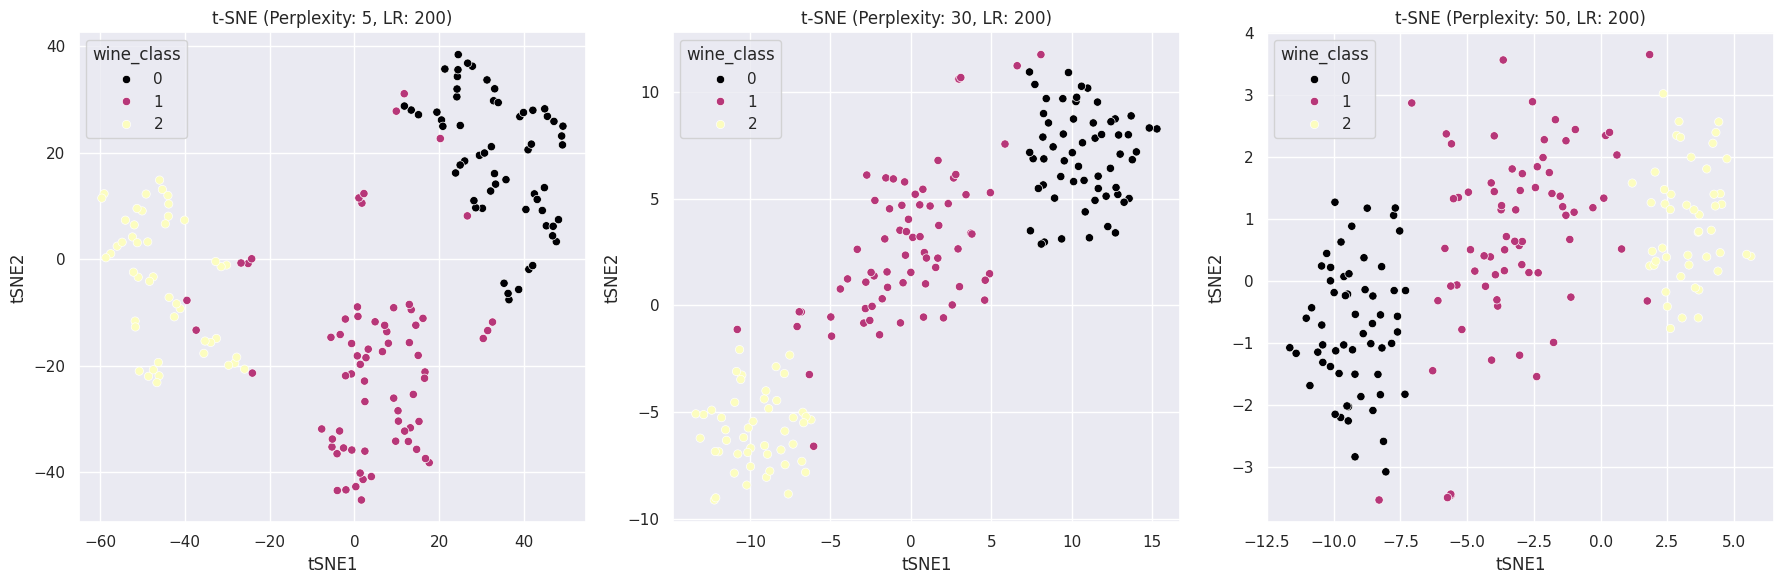

In [29]:
tsne_results = {}
perplexities = [5, 30, 50]
learning_rates = [200]

for perp in perplexities:
    for lr in learning_rates:
        tsne = TSNE(n_components=2, perplexity=perp, learning_rate=lr, random_state=42, init='pca')
        X_tsne = tsne.fit_transform(X_scaled)

        df_tsne = pd.DataFrame(X_tsne, columns=['tSNE1', 'tSNE2'])
        df_tsne['wine_class'] = y
        tsne_results[(perp, lr)] = df_tsne

fig, axes = plt.subplots(1, len(perplexities), figsize=(18, 6))
for i, (perp, lr) in enumerate(tsne_results):
    df_plot = tsne_results[(perp, lr)]
    sns.scatterplot(
        x='tSNE1',
        y='tSNE2',
        hue='wine_class',
        data=df_plot,
        palette='magma',
        legend='full',
        ax=axes[i]
    )
    axes[i].set_title(f't-SNE (Perplexity: {perp}, LR: {lr})')
    axes[i].grid(True)

plt.tight_layout()
plt.show()



### 3. **Comparación entre PCA y t-SNE**

* Contrastar las visualizaciones y discutir las **ventajas y limitaciones** de cada técnica:

  * PCA como método **lineal** para interpretar varianza y relaciones globales.
  * t-SNE como método **no lineal** que preserva relaciones locales y vecindades.
* Evaluar en qué escenarios prácticos sería más recomendable usar PCA (interpretabilidad, reducción previa para modelos) o t-SNE (exploración y visualización de clústeres).
* Reflexionar sobre la **importancia de la reducción de dimensionalidad** en datasets de alta dimensión como Wine, destacando su utilidad para:

  * Visualizar patrones ocultos en los datos.
  * Reducir complejidad y ruido antes de aplicar algoritmos de aprendizaje automático.
  * Facilitar la interpretación y comunicación de resultados.



#Ventajas
PCA:
*   Interpretabilidad a través de los loadings.
*   Maximiza la varianza global.
*   Rápido y determinista (con resultados consistentes).

TSNE:
*   Visualización superior (clústeres más compactos y definidos).
*   Capaz de capturar y mostrar relaciones no lineales.

#Limitacines
PCA:
*   No puede capturar relaciones o estructuras no lineales en los datos.
*   Es sensible a la escala de los datos, por lo que requiere preprocesamiento (estandarización)
*  Todas las PC son combinaciones de las variables originales, lo que puede hacer difícil la interpretación si muchas variables tienen loadings altos.

TSNE:
*   La distancia entre clústeres no es interpretable.
*   Sensibilidad a hiperparámetros
*   Es lento y estocástico (los resultados pueden variar ligeramente entre ejecuciones).

#Evaluar escenarios
PCA: Ideal para reducción de ruido, de previa de alta dimensión antes de usar otro algoritmo y para entender la estructura de la varianza.

TSNE: Ideal para la exploración de datos y visualización de clústeres cuando la interpretabilidad de las dimensiones no es prioridad.

#Reducción de dimensionalidad
Es imposible visualizar 13 dimensiones, pero al reducirlas se puede ver que los vinos se agrupan en tres categorías distintas. PCA y TSNE revelaron que las clases están inherentemente separadas en el espacio de características químicas.
Al seleccionar solo las primeras 2 o 3 PC, se está filtrando la información menos importante (ruido) que no contribuye significativamente a la varianza global. Esto puede mejorar el rendimiento de algoritmos de Machine Learning posteriores.

Aunque PCA ofrece interpretaciones directas, al ver un gráfico TSNE con clústeres muy compactos, es más fácil comunicar visualmente los resultados y convencer al equipo de que las clases están bien definidas.